In [2]:
from strategies_utils import get_match_df, analyze_strategies, get_best_leagues, get_best_strategies, compare_strategies

df = get_match_df()

df.tail()

/home/maicolnicolini/code/bet-master-analytics/src/strategies/strategies_utils.py:132: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  df_final = df_final[other_strategies_mask | dnb_mask]


,date,time,league,home_team,away_team,goal_home,goal_away,strategy,result,return,week
match_id,,,,,,,,,,,
d19484899,2026-05-01,19:30,National,Fleury 91,Le Puy-en-Velay,4,0,BTTS,False,-1.0,17
d19443210,2026-05-01,16:00,Turchia,Rizespor,Konyaspor,3,2,DNB 1,True,0.4,17
d19509430,2026-05-01,15:00,Serie B,Calcio Padova,Pescara,1,0,BTTS,False,-1.0,17
d19674750,2026-05-01,13:35,Cina,Shandong Taishan,Qingdao West Coast,1,1,Goal Home HT Optuna,False,-1.0,17
d19674751,2026-05-01,13:35,Cina,Tianjin Jinmen Tiger,Wuhan Three Towns,2,2,Over 2.5 Optuna,True,0.8,17


## Approccio 1: Scommetto tutti i mercati e tutti i campionati

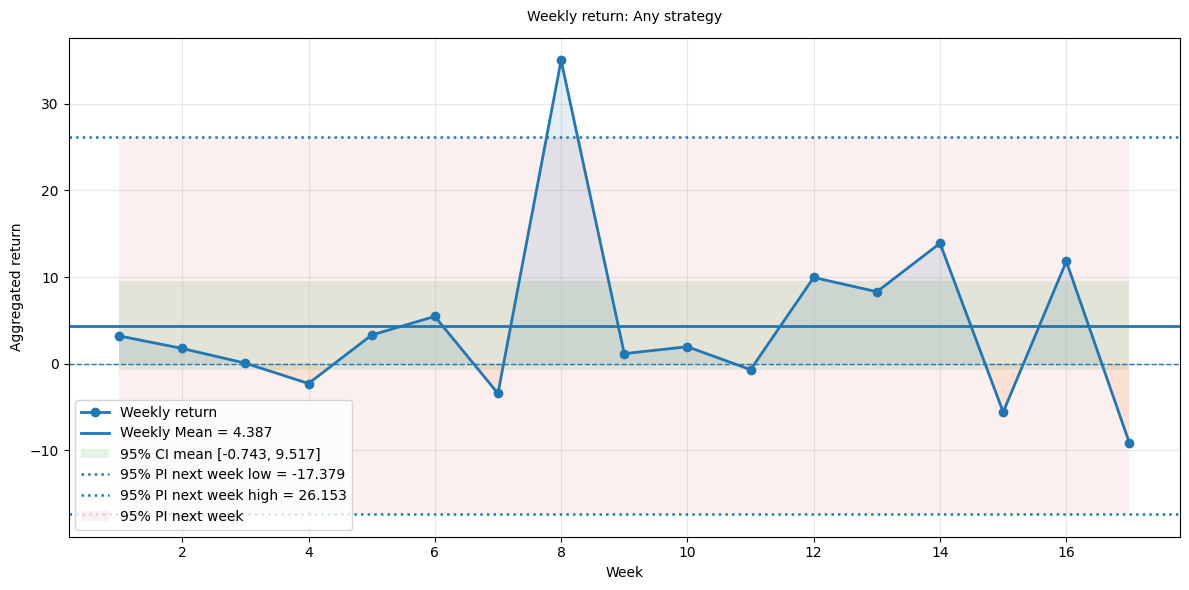

In [3]:
weekly_return, stats = analyze_strategies(df, print_pi=True)

95% PI è la probabilità che il ritorno della prossima settimana sia compreso fra PI low e PI high
### Note:
1. Ritorno medio è positivo ma a estremo inferiore CI negativo -> non è detto che il vero valor medio del ritorno settimanale è > 0
2. 95% PI estremamente variabile

## Approccio 2: scommetto i mercati che si comportano meglio su tutti i campionati

In [4]:
strategy_df = get_best_strategies(df)
strategy_df

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
Over 1.5 Optuna,3.65,6.62,12.82,32.93,218,0.72
Goal Home HT Optuna,2.07,7.18,2.71,6.53,46,0.54
BTTS,1.80,7.72,4.59,7.31,78,0.73
Over 1.5 (M2-X),0.85,1.89,7.29,5.80,124,0.77
DNB 1,0.37,1.92,7.53,4.03,128,0.74
Goal HT,0.28,1.74,5.06,3.49,86,0.74
Win 1,0.27,0.80,2.06,1.98,35,0.79
Over 0.5 HT (Live),0.06,1.44,5.41,4.15,92,0.76
Goal Home HT,-0.19,1.20,1.65,1.53,28,0.69
Multigoal 1-2 Home,-0.27,1.45,1.47,1.29,25,0.60


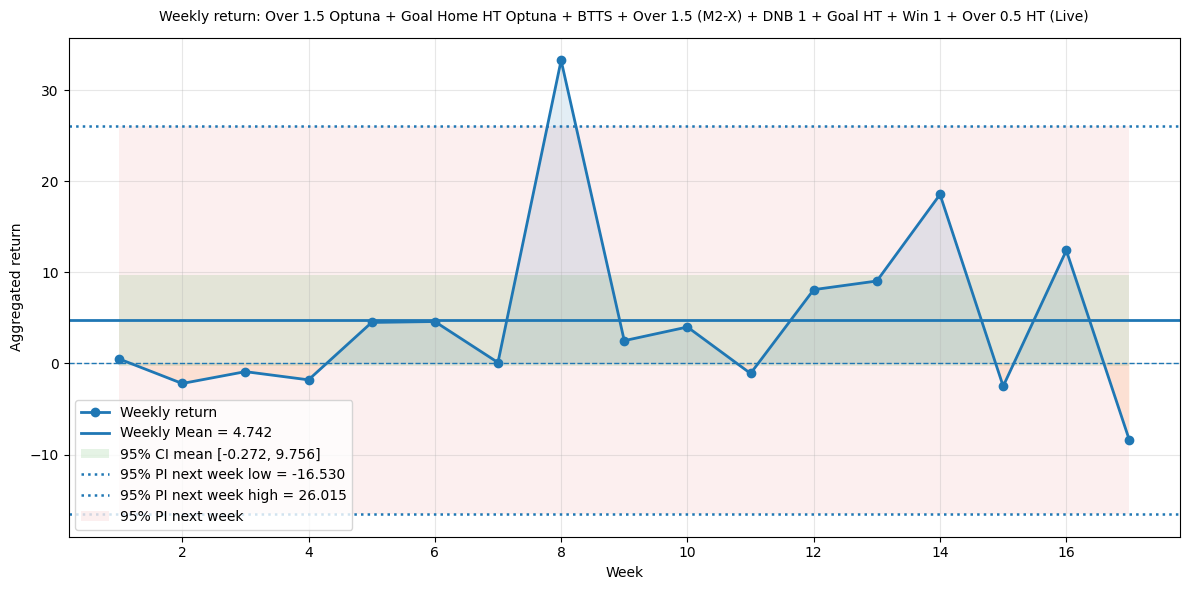

In [5]:
# Tolgo mercati con ritorno medio settimanale negativo e analizzo le strategie
best_strategies = strategy_df[strategy_df["weekly_mean_return"] > 0].index.to_list()
weekly_return, stats = analyze_strategies(df, strategies=best_strategies, print_pi=True)

### Note:
- Valor medio leggermente più alto ma meno confidente (CI mean)
- Intervallo PI maggiore -> più volatile
- Andando a vedere sopra, BTTS è quello che porta più ritorno ma è quello più volatile (ha performato particolarmente bene in week 7), provo a toglierlo

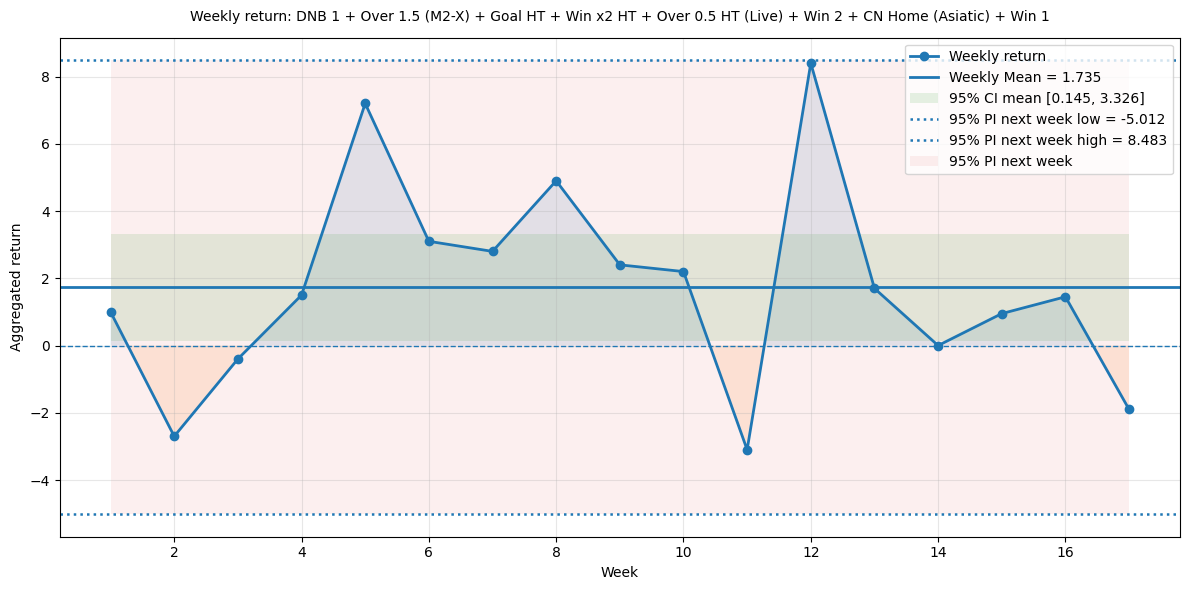

In [6]:
weekly_return, stats = analyze_strategies(df, strategies=['DNB 1', 'Over 1.5 (M2-X)', 'Goal HT', 'Win x2 HT', 'Over 0.5 HT (Live)', 'Win 2', 'CN Home (Asiatic)', 'Win 1'], print_pi=True)

### Note:
- ritorno medio minore ma CI low > 0 -> al 95% il ritorno medio settimanale è positivo
- PI molto meno variabile

## Approccio 3: scommetto solo sui campionati migliori

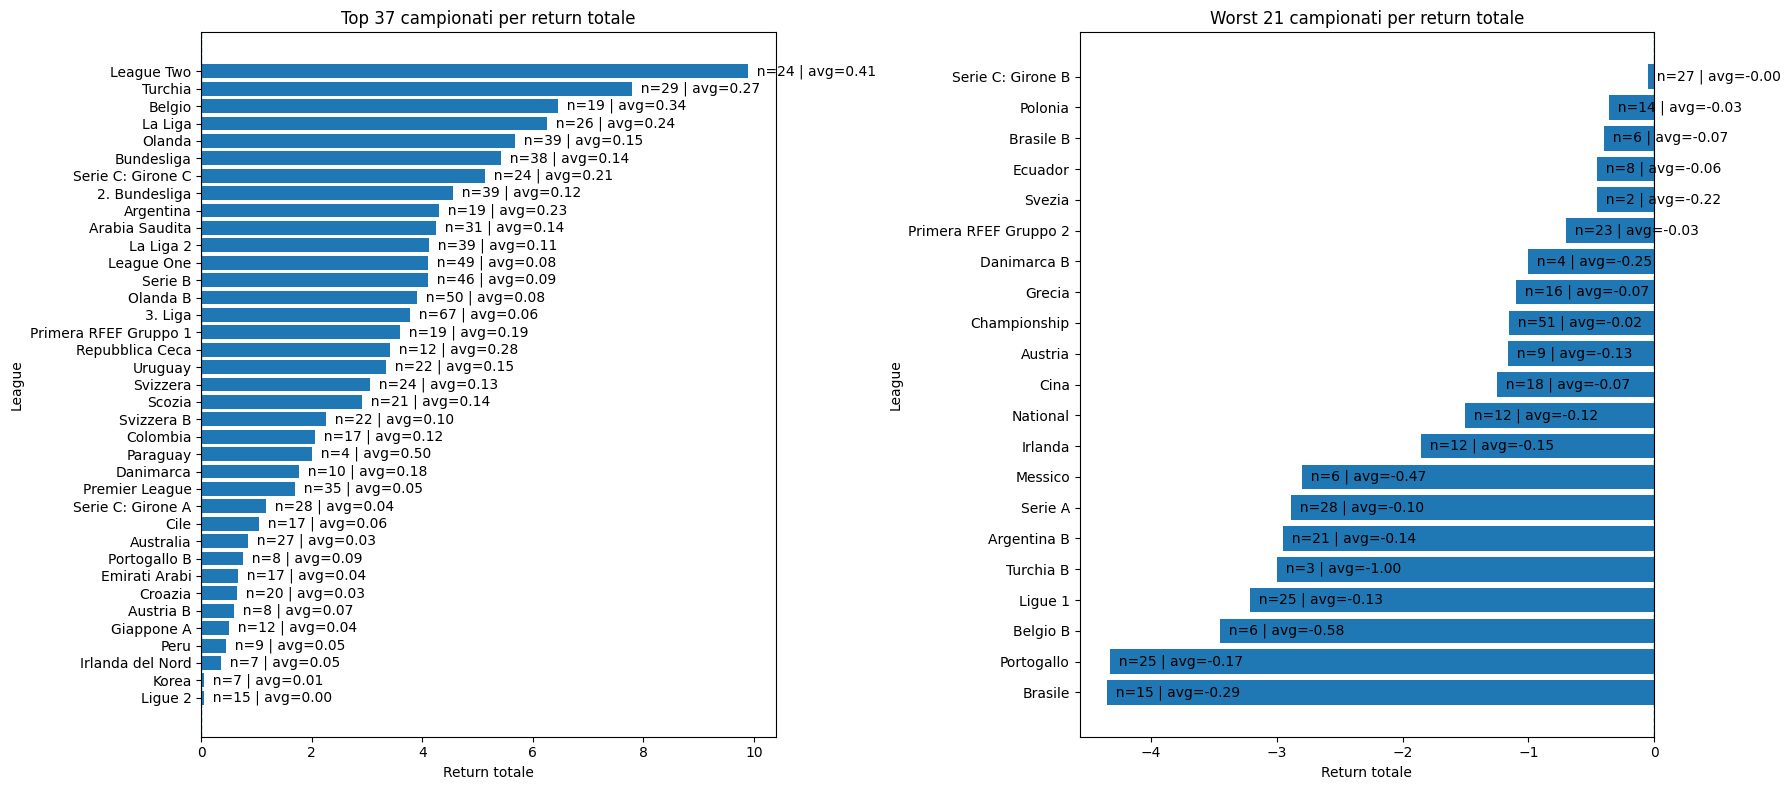

In [7]:
best_leagues = get_best_leagues(df)

In [8]:
threshold = best_leagues["n_matches"].quantile(q=0.1)
print(f"Threshold: {threshold}")
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

Threshold: 8.0


In [9]:
# Vedo quali sono le migliori scommesse per i campionati con ritorno positivo (considero solo campionati grafico a sx)
get_best_strategies(df, leagues=league_list)

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
Over 1.5 Optuna,4.71,6.15,10.76,27.90,183,0.77
Goal Home HT Optuna,2.40,3.50,1.59,3.93,27,0.61
BTTS,1.46,5.82,3.82,5.46,65,0.73
Over 1.5 (M2-X),0.80,1.42,4.35,3.51,74,0.80
DNB 1,0.70,1.79,5.41,3.05,92,0.80
Win 1,0.53,0.69,1.47,0.98,25,0.88
Over 0.5 HT (Live),0.38,1.16,4.24,3.39,72,0.81
Goal Home HT,-0.27,1.21,1.41,1.42,24,0.65
DNB 2,-0.27,1.41,2.65,2.89,45,0.73
Win 2,-0.42,1.10,1.00,0.84,17,0.53


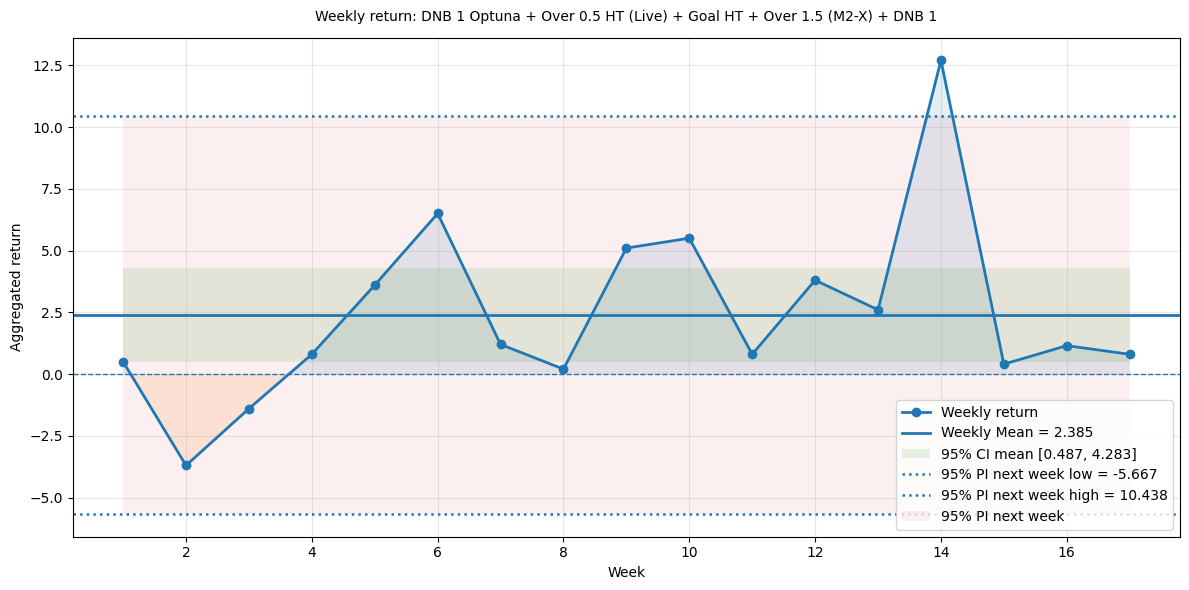

In [10]:
# Prendo le strategie migliori togliendo CN Home perchè ha ritorno negativo e BTTS per alta volatilità
best_strategies = ['DNB 1 Optuna', 'Over 0.5 HT (Live)', 'Goal HT', 'Over 1.5 (M2-X)', 'DNB 1']

weekly_return, stats_1 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

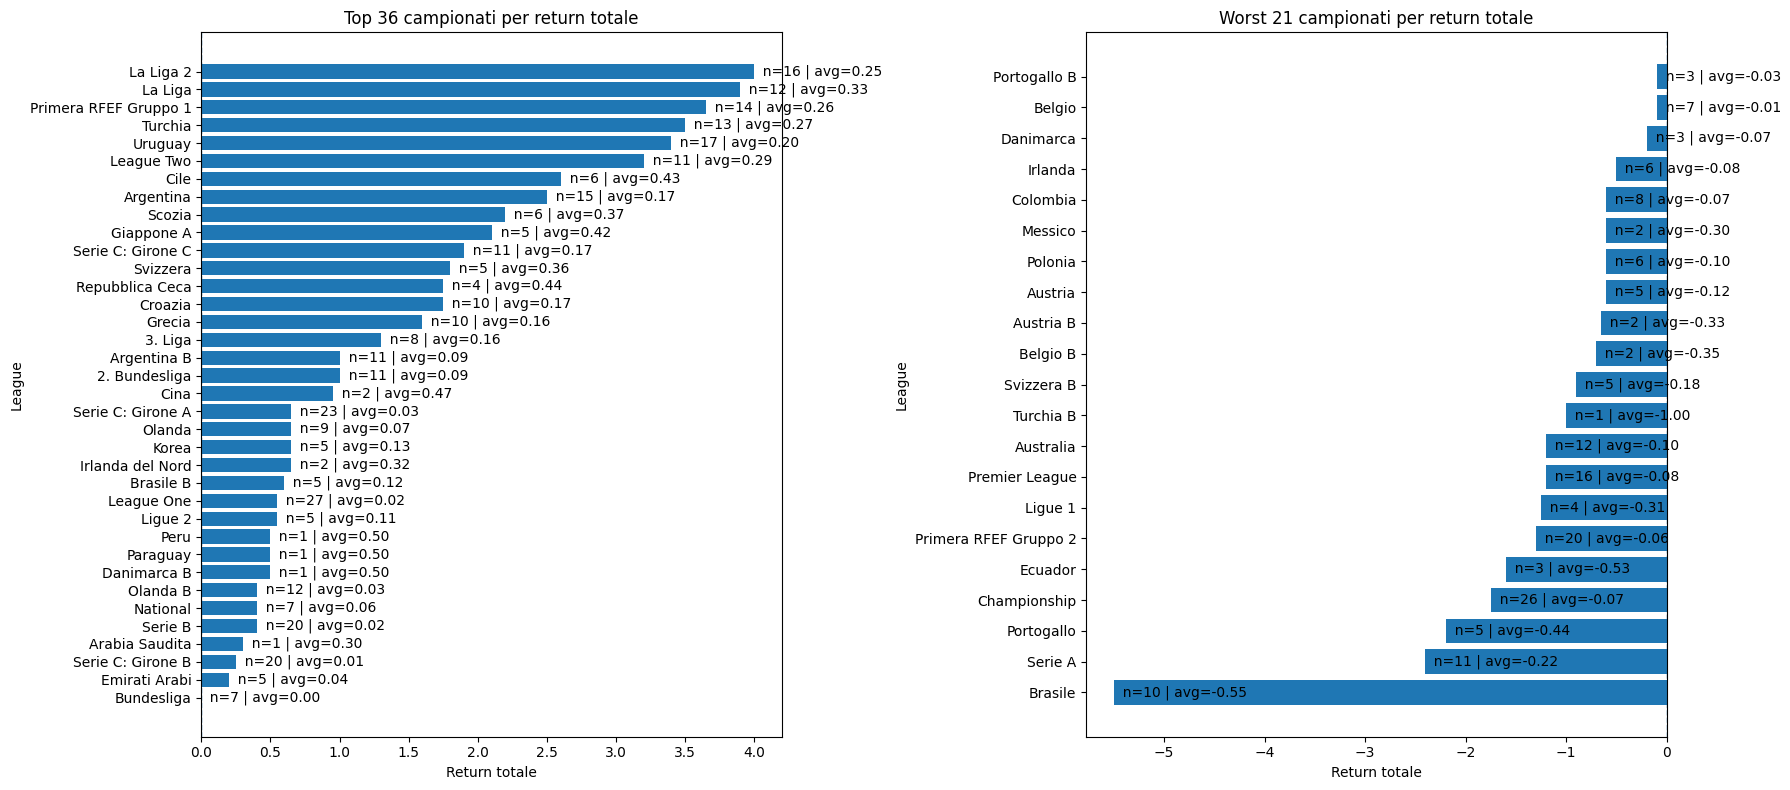

Threshold: 1.5


In [11]:
# Find the best leageus for the best strategies 
best_leagues = get_best_leagues(df, strategies=best_strategies)
threshold = best_leagues["n_matches"].quantile(q=0.1)
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

print(f"Threshold: {threshold}")

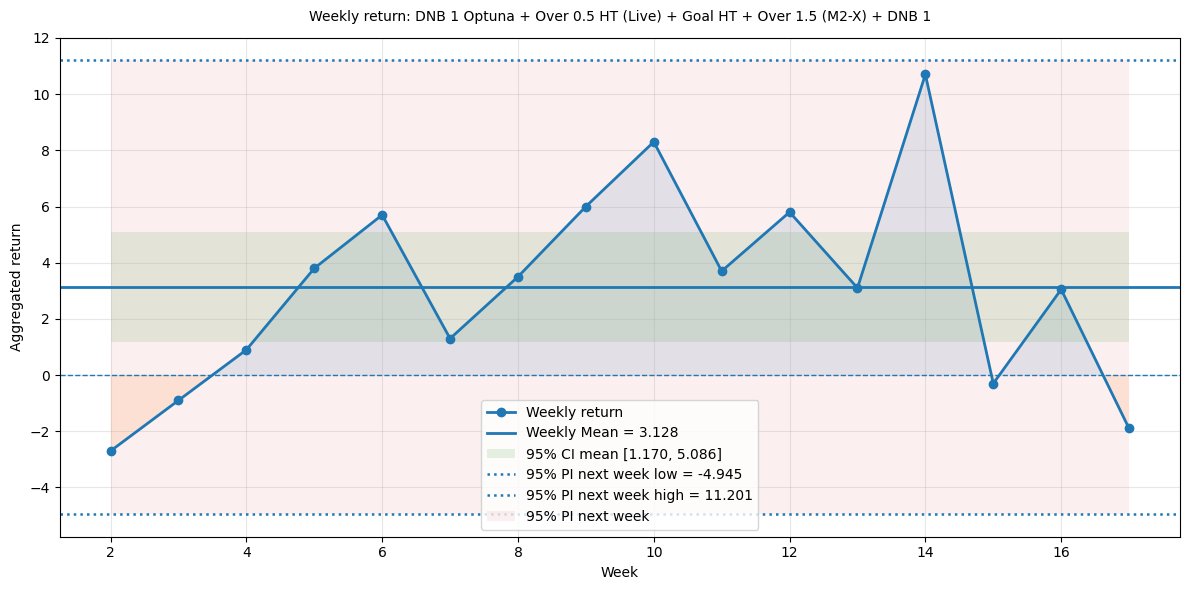

In [12]:
weekly_return, stats_2 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

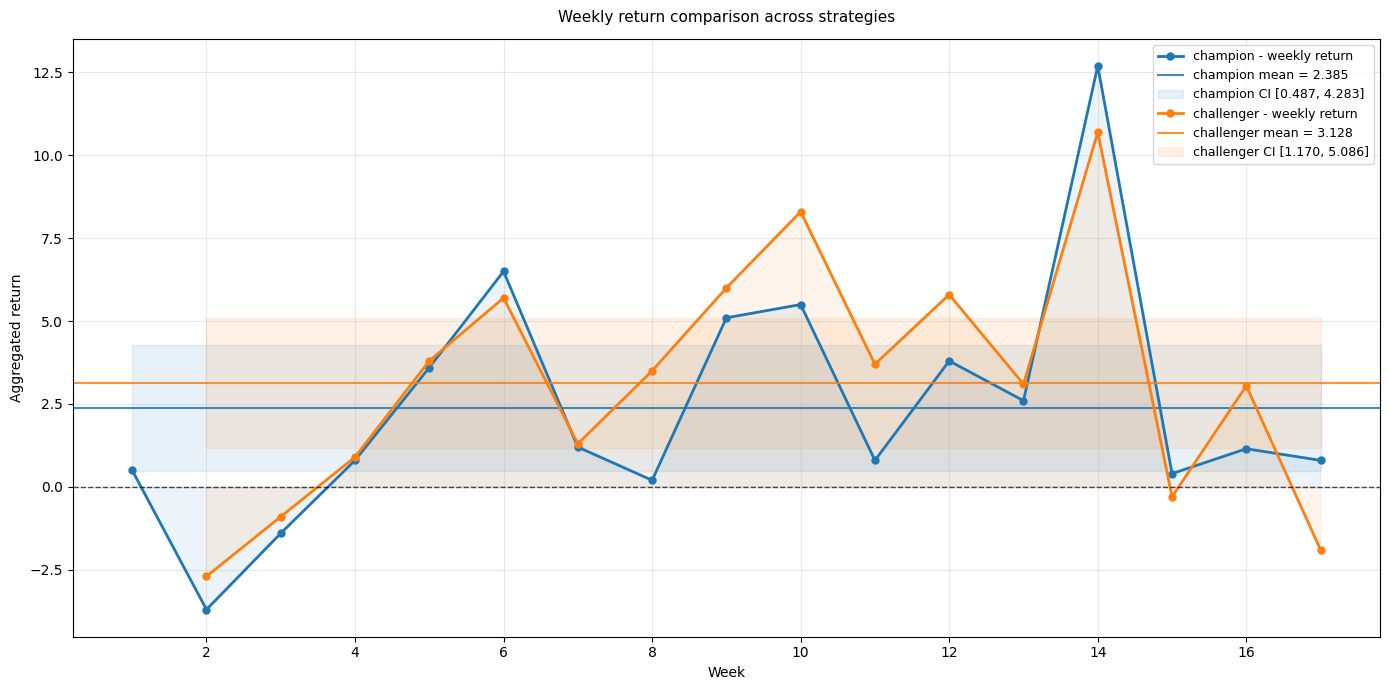

In [13]:
strategies_to_compare = {"champion": stats_1, "challenger": stats_2}

aggregated_data, summary_df = compare_strategies(
    df=df,
    strategies=strategies_to_compare,
    show_ci=True,
    show_pi=False
)

In [14]:
summary_df

,label,strategy,leagues,n_weeks,expected_bets_per_week,mean_weekly_agg_return,std_weekly_agg_return,sem,ci_low,ci_high,pi_low,pi_high
0,champion,"[DNB 1 Optuna, Over 0.5 HT (Live), Goal HT, Ov...","[League Two, Turchia, Belgio, La Liga, Olanda,...",17,17,2.39,3.69,0.90,0.49,4.28,-5.67,10.44
1,challenger,"[DNB 1 Optuna, Over 0.5 HT (Live), Goal HT, Ov...","[La Liga 2, La Liga, Primera RFEF Gruppo 1, Tu...",16,21,3.13,3.67,0.92,1.17,5.09,-4.95,11.20


In [65]:
set(summary_df.iloc[1]['strategy'])

{'DNB 1', 'DNB 1 Optuna', 'Goal HT', 'Over 0.5 HT (Live)', 'Over 1.5 (M2-X)'}

### Note:
- Ritorno medio più alto del precedente ma ancora minore del primo
- Confidenza molto più alta sia del primo che del secondo (CI low 1.5 vuol dire che il valor medio sul lungo periodo è almeno 1.53 al 95% di confidenza)
- Variabilità sulla settimana (PI) maggiore di prima ma più spostato verso l'alto